# Ultra-long rollouts

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys

parrot_color = np.array([46, 69, 81]) / 255
dynamix_color = np.array([152, 199, 71]) / 255
simplex_color = np.array([234, 57, 89]) / 255
chronos_color = np.array([80, 155, 143]) / 255

dynamix_color = np.array([109, 180, 156]) / 255
chronos_color = np.array([85, 158, 162]) / 255
parrot_color = np.array([242, 163, 65]) / 255

plt.rcParams["font.family"] = "Helvetica"

In [ ]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# Example: x is your 1D time series, fs is the sampling frequency in Hz
# x: np.ndarray of shape (N,)
# fs: float

def find_psd(x, fs):
    """
    Compute and plot the power spectral density of a univariate time series 
    using Welch's method.

    Args:
        x (np.ndarray): 1D time series array.
        fs (float): Sampling frequency in Hz.

    Returns:
        freqs (np.ndarray): Frequency values in Hz.
        psd (np.ndarray): Power spectral density estimate.
    """
    # Remove mean to avoid a large DC peak
    x_demeaned = x - np.mean(x)


    # Welch PSD estimate
    # nperseg can be tuned; here use 1/8 of the series length as a simple default
    nperseg = max(256, len(x_demeaned) // 8)
    freqs, psd = signal.welch(
        x_demeaned,
        fs=fs,
        nperseg=nperseg,
        detrend="constant",
        scaling="density",  # PSD units: power / Hz
        window="hann"
    )

    # Remove frequencies above the Nyquist frequency
    return freqs, psd

In [42]:
from dysts.flows import DoublePendulum, Lorenz, Rossler, Chua

CONTEXT_LENGTH = 2000
FORECAST_LENGTH = 10000

np.random.seed(0)
eq = Lorenz()
# eq = DoublePendulum()
# eq = Rossler()
# eq = Chua()
eq.ic += 0.05


# traj = eq.make_trajectory(500 + CONTEXT_LENGTH + FORECAST_LENGTH, standardize=True)[500:]
# traj.dump(eq.name + "_long_trajectory.npy")

traj = np.load("./private_development/" + eq.name + "_long_trajectory.npy", allow_pickle=True)
traj_context = traj[:CONTEXT_LENGTH, :]
traj_true = traj[2000:, :]


In [43]:
import sys
# sys.path.append('.')
sys.path.append('./DynaMix/')

import torch
# from src.model.dynamix import DynaMix
from src.model.forecaster import DynaMixForecaster
# from src.metrics.metrics import geometrical_misalignment, temporal_misalignment, MASE
# from src.utilities.plotting_eval import plot_3D_attractor, plot_2D_attractor, plot_TS_forecast
from src.utilities.utilities import load_hf_model

# Load the pre-trained model
model = load_hf_model("dynamix-3d-alrnn-v1.0")
model.eval() # Set model to evaluation mode
forecaster = DynaMixForecaster(model) # Initialize the forecaster


context_traj_tensor  = torch.tensor(traj_context)
with torch.no_grad(): 
    reconstruction = forecaster.forecast(
        context=context_traj_tensor,
        horizon=FORECAST_LENGTH, # Match the horizon of the ground truth
        standardize=False,
    )
traj_pred = reconstruction.detach().numpy()

/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: divide by zero encountered in matmul
  K = R.T @ R / M + np.eye(M)
/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: overflow encountered in matmul
  K = R.T @ R / M + np.eye(M)
/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: invalid value encountered in matmul
  K = R.T @ R / M + np.eye(M)


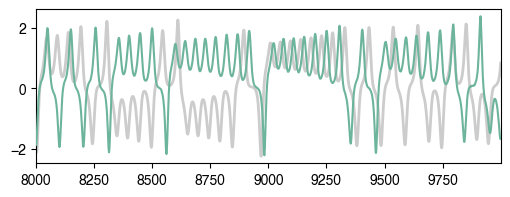

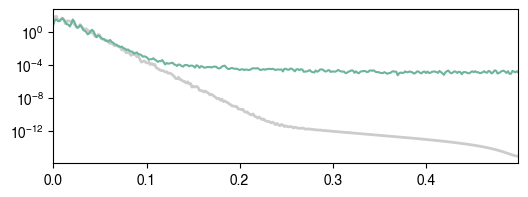

In [44]:
import degas as dg
plt.figure(figsize=(6, 2))
traj_inds = np.arange(traj_true.shape[0] - 2000, traj_true.shape[0])
plt.plot(traj_inds, traj_true[-2000:, 0], color=0.8*np.ones(3), linewidth=2)
plt.plot(traj_inds, traj_pred[-2000:, 0], zorder=10, color=dynamix_color)
plt.xlim(traj_inds[0], traj_inds[-1])
dg.better_savefig(f"../analysis/dynamix_long_forecast_{eq.name}.pdf", dpi=300, transparent=True, pad_inches=0.25)

plt.figure(figsize=(6, 2))
freqs_true, psd_true = find_psd(traj_true[-5000:, 0], 1)
freqs_pred, psd_pred = find_psd(traj_pred[-5000:, 0], 1)
plt.semilogy(freqs_true, psd_true, color=0.8*np.ones(3), linewidth=2)
plt.semilogy(freqs_pred, psd_pred, color=dynamix_color)
plt.xlim(np.min(freqs_true), np.max(freqs_true))
dg.better_savefig(f"../analysis/dynamix_psd_{eq.name}.pdf", dpi=300, transparent=True, pad_inches=0.25)

In [45]:
import sys
sys.path.append('..')
from models.parrot import context_parroting_forecast
traj_pred = list()
for mode in range(traj_context.shape[1]):
    traj_pred_mode = context_parroting_forecast(traj_context[:, mode], forecast_total_length=FORECAST_LENGTH)[2]
    traj_pred.append(traj_pred_mode.copy())
traj_pred = np.array(traj_pred).T

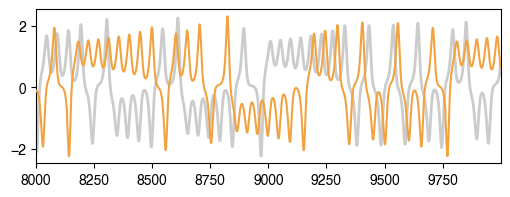

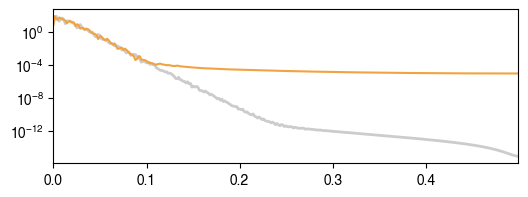

In [46]:

plt.figure(figsize=(6, 2))
traj_inds = np.arange(traj_true.shape[0] - 2000, traj_true.shape[0])
plt.plot(traj_inds, traj_true[-2000:, 0], color=0.8*np.ones(3), linewidth=2)
plt.plot(traj_inds, traj_pred[-2000:, 0], zorder=10, color=parrot_color)
plt.xlim(traj_inds[0], traj_inds[-1])
dg.better_savefig(f"../analysis/parrot_long_forecast_{eq.name}.pdf", dpi=300, transparent=True, pad_inches=0.25)

plt.figure(figsize=(6, 2))
freqs_true, psd_true = find_psd(traj_true[-5000:, 0], 1)
freqs_pred, psd_pred = find_psd(traj_pred[-5000:, 0], 1)
plt.semilogy(freqs_true, psd_true, color=0.8*np.ones(3), linewidth=2)
plt.semilogy(freqs_pred, psd_pred, color=parrot_color)
plt.xlim(np.min(freqs_true), np.max(freqs_true))
dg.better_savefig(f"../analysis/parrot_psd_{eq.name}.pdf", dpi=300, transparent=True, pad_inches=0.25)

In [47]:
import torch
from chronos import BaseChronosPipeline, ChronosPipeline, ChronosBoltPipeline

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",  # use "amazon/chronos-bolt-small" for the corresponding Chronos-Bolt model
    device_map="mps",
    torch_dtype=torch.bfloat16,
)

traj_pred = list()
for mode in range(traj_context.shape[1]):
    forecast = pipeline.predict(
        inputs=torch.tensor(traj_context[:, mode]),
        prediction_length=FORECAST_LENGTH,
        num_samples=20,
        limit_prediction_length=False,
        )
    traj_pred_mode = np.mean(forecast[0, :, :].detach().numpy(), axis=0)
    traj_pred.append(traj_pred_mode)
traj_pred = np.array(traj_pred).T

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


KeyboardInterrupt: 

In [48]:
# traj_pred.dump(f"chronos_{eq.name}_forecast.npy")
traj_pred = np.load(f"./private_development//chronos_{eq.name}_forecast.npy", allow_pickle=True)

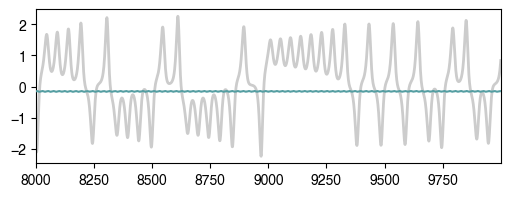

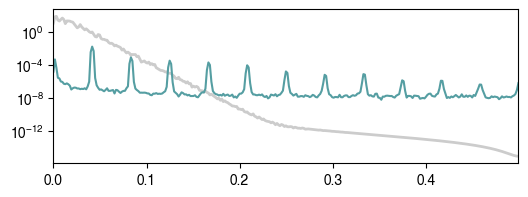

In [49]:
plt.figure(figsize=(6, 2))
traj_inds = np.arange(traj_true.shape[0] - 2000, traj_true.shape[0])
plt.plot(traj_inds, traj_true[-2000:, 0], color=0.8*np.ones(3), linewidth=2)
plt.plot(traj_inds, traj_pred[-2000:, 0], zorder=10, color=chronos_color)
plt.xlim(traj_inds[0], traj_inds[-1])
dg.better_savefig(f"../analysis/chronos_long_forecast_{eq.name}.pdf", dpi=300, transparent=True, pad_inches=0.25)


plt.figure(figsize=(6, 2))
freqs_true, psd_true = find_psd(traj_true[-5000:, 0], 1)
freqs_pred, psd_pred = find_psd(traj_pred[-5000:, 0], 1)
plt.semilogy(freqs_true, psd_true, color=0.8*np.ones(3), linewidth=2)
plt.semilogy(freqs_pred, psd_pred, color=chronos_color)
plt.xlim(np.min(freqs_true), np.max(freqs_true))
dg.better_savefig(f"../analysis/chronos_psd_{eq.name}.pdf", dpi=300, transparent=True, pad_inches=0.25)

0.6940725853665053


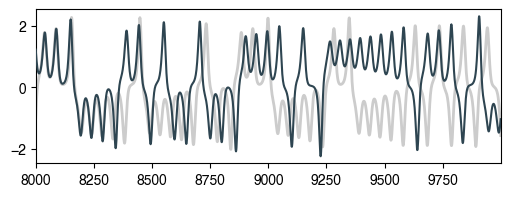

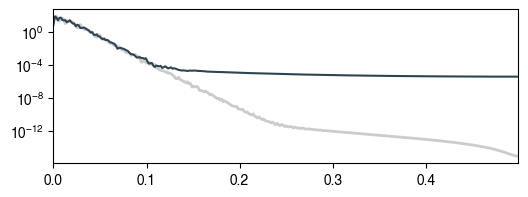

In [247]:
CONTEXT_LENGTH = 3000

eq = Lorenz()
traj = np.load(eq.name + "_long_trajectory.npy", allow_pickle=True)
traj_context = traj[:CONTEXT_LENGTH, :]
traj_true = traj[CONTEXT_LENGTH:, :]


import sys
sys.path.append('../..')
from models.parrot import context_parroting_forecast
traj_pred = list()
for mode in range(traj_context.shape[1]):
    traj_pred_mode = context_parroting_forecast(traj_context[:, mode], forecast_total_length=FORECAST_LENGTH)[2]
    traj_pred.append(traj_pred_mode.copy())
traj_pred = np.array(traj_pred).T

plt.figure(figsize=(6, 2))
traj_inds = np.arange(8000, 10000)
plt.plot(traj_inds, traj_true[8000-CONTEXT_LENGTH:10000-CONTEXT_LENGTH, 0], color=0.8*np.ones(3), linewidth=2)
plt.plot(traj_inds, traj_pred[8000-CONTEXT_LENGTH:10000-CONTEXT_LENGTH, 0], zorder=10, color=parrot_color)
plt.xlim(traj_inds[0], traj_inds[-1])
dg.better_savefig(f"../../analysis/parrot_long_forecast_{eq.name}_context_{CONTEXT_LENGTH}.pdf", dpi=300, transparent=True, pad_inches=0.25)


plt.figure(figsize=(6, 2))
freqs_true, psd_true = find_psd(traj_true[-5000:, 0], 1)
freqs_pred, psd_pred = find_psd(traj_pred[-5000:, 0], 1)
plt.semilogy(freqs_true, psd_true, color=0.8*np.ones(3), linewidth=2)
plt.semilogy(freqs_pred, psd_pred, color=parrot_color)
plt.xlim(np.min(freqs_true), np.max(freqs_true))
dg.better_savefig(f"../../analysis/parrot_psd_{eq.name}_context_{CONTEXT_LENGTH}.pdf", dpi=300, transparent=True, pad_inches=0.25)

from dysts.metrics import average_hellinger_distance
print(average_hellinger_distance(traj_true, traj_pred))

In [ ]:
all_all_distances = list()
for trajectory in sorted(glob.glob("../../data/long_trajectories/*.npy")):
    equation_name = trajectory.split("/")[-1].split(".")[0]
    print(equation_name, flush=True)

    traj = np.load(trajectory, allow_pickle=True)
    traj = (traj - np.mean(traj, axis=0)) / np.std(traj, axis=0)


    all_distances = list()
    context_lengths = np.linspace(100, 3000, 100).astype(int)
    for context_length in context_lengths:
        traj_context = traj[:context_length, :]
        traj_true = traj[context_length:, :]
        traj_pred = list()
        for mode in range(traj_context.shape[1]):
            traj_pred_mode = context_parroting_forecast(traj_context[:, mode], forecast_total_length=FORECAST_LENGTH)[2]
            traj_pred.append(traj_pred_mode.copy())
        traj_pred = np.array(traj_pred).T
        # print(average_hellinger_distance(traj_true, traj_pred))
        all_distances.append(average_hellinger_distance(traj_true, traj_pred))
    all_all_distances.append(np.array(all_distances))
    


Aizawa
AnishchenkoAstakhov
Arneodo
ArnoldBeltramiChildress
ArnoldWeb
AtmosphericRegime
BeerRNN
BelousovZhabotinsky
BickleyJet
Blasius
BlinkingRotlet
BlinkingVortex
Bouali
Bouali2
BurkeShaw
CaTwoPlus
CaTwoPlusQuasiperiodic
CellCycle
CellularNeuralNetwork
Chen
ChenLee
Chua
CircadianRhythm
CoevolvingPredatorPrey
Colpitts
Coullet
Dadras
DequanLi
DoubleGyre
DoublePendulum
Duffing
ExcitableCell
Finance
ForcedBrusselator
ForcedFitzHughNagumo
ForcedVanDerPol
GenesioTesi
GlycolyticOscillation
GuckenheimerHolmes
Hadley
Halvorsen
HastingsPowell
HenonHeiles
HindmarshRose
Hopfield
HyperBao
HyperCai
HyperJha
HyperLorenz
HyperPang
HyperQi
HyperRossler
HyperWang
HyperXu
HyperYan
HyperYangChen
IkedaDelay
InteriorSquirmer
IsothermalChemical
ItikBanksTumor
JerkCircuit
KawczynskiStrizhak
Laser
LidDrivenCavityFlow
LiuChen
Lorenz
Lorenz84
Lorenz96
LorenzBounded
LorenzCoupled
LorenzStenflo
LuChen
LuChenCheng
MacArthur
MackeyGlass
MooreSpiegel
MultiChua
NewtonLiepnik
NoseHoover
NuclearQuadrupole
OscillatingFl

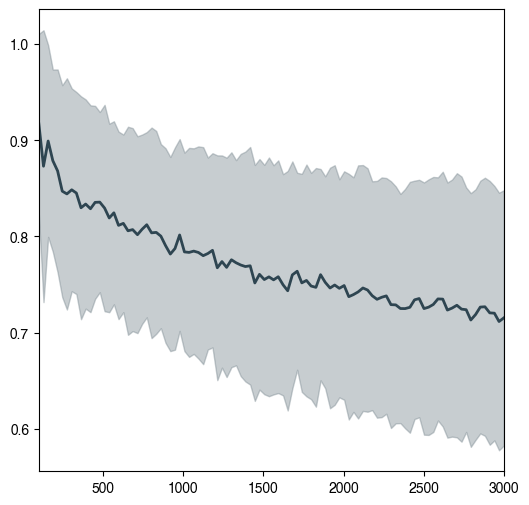

In [ ]:
import degas as dg
all_all_distances = np.array(all_all_distances)
plt.figure(figsize=(6, 6))
dg.plot_err(
    np.mean(all_all_distances, axis=0), 
    np.std(all_all_distances, axis=0), 
    linewidth=2,
    x=context_lengths, 
    color=parrot_color
)
plt.xlim(context_lengths[0], context_lengths[-1])

dg.better_savefig(f"../../analysis/parrot_hellinger_distance_vary_context.pdf", dpi=300, transparent=True, pad_inches=0.25)